## Import Required libraries

In [1]:
import os 
import mne
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# sklearn packages
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    ConfusionMatrixDisplay,
    accuracy_score
)

# Parametric T-SNE
import sys
sys.path.append("..") 
from parametric_tsne.parametric_tSNE import Parametric_tSNE

# tensorflow packages
import tensorflow as tf
#import tensorflow_addons as tfa
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (LSTM, 
                                    Dropout, 
                                    Dense, 
                                    Input)
from tensorflow.keras.layers import (LSTM, 
                                    Dense, 
                                    Dropout, 
                                    LeakyReLU, 
                                    BatchNormalization)
from tensorflow.keras.losses import (SparseCategoricalCrossentropy, 
                                     CategoricalCrossentropy, 
                                     CategoricalFocalCrossentropy)
from tensorflow.keras.optimizers import (Adam, 
                                        AdamW
                                        )         
from tensorflow.keras.utils import to_categorical                         
from tensorflow.keras.callbacks import (EarlyStopping, 
                                        ModelCheckpoint,
                                        TensorBoard)

/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
BATCH_SIZE = 32
TRAIN_FILE_PATH = "../data/mne/train.npz"
VALID_FILE_PATH = "../data/mne/valid.npz"
TEST_FILE_PATH = "../data/mne/test.npz"

## Step 1 : Load Data & Convert into Tensor 

In [14]:
# Train
train = np.load(TRAIN_FILE_PATH)
X_train, y_train = train["arr_0"], train["arr_1"].astype(int)

# Valid
valid = np.load(VALID_FILE_PATH)
X_valid, y_valid = valid["arr_0"], valid["arr_1"].astype(int)

# Test
test = np.load(TEST_FILE_PATH)
X_test, y_test = test["arr_0"], test["arr_1"].astype(int)

print(f"Shape of X_train : {X_train.shape} and y_train : {y_train.shape}")
print(f"Shape of X_val : {X_valid.shape} and y_valid : {y_valid.shape}")
print(f"Shape of X_test : {X_test.shape} and y_test : {y_test.shape}")

Shape of X_train : (20776, 320) and y_train : (20776,)
Shape of X_val : (3596, 320) and y_valid : (3596,)
Shape of X_test : (3686, 320) and y_test : (3686,)


In [15]:
# Removing Class 0 from the Feature Variables
X_train = X_train[(y_train != 0)]
X_valid = X_valid[(y_valid != 0)]
X_test = X_test[(y_test != 0)]

# Removing Class 0 from the target Variable 
y_train = y_train[(y_train != 0)]
y_valid = y_valid[(y_valid != 0)]
y_test = y_test[(y_test != 0)]

In [16]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

In [17]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling
sc = StandardScaler()
sc.fit(X_train)

# Transform X_train, X_valid, and X_test
X_train = sc.transform(X_train)
X_valid = sc.transform(X_valid)
X_test = sc.transform(X_test)

In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(y_train)

LabelEncoder()

In [20]:
y_train = le.transform(y_train)
y_valid = le.transform(y_valid)
y_test = le.transform(y_test)

In [21]:
# to Categorical 
y_train = to_categorical(y_train)
y_valid = to_categorical(y_valid) 
y_test  = to_categorical(y_test)


training_dataset = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
                        .shuffle(buffer_size = 42)
                        .batch(BATCH_SIZE)
                        .prefetch(tf.data.AUTOTUNE))
validation_dataset = (tf.data.Dataset.from_tensor_slices((X_valid, y_valid))
                        .shuffle(buffer_size = 42)
                        .batch(BATCH_SIZE)
                        .prefetch(tf.data.AUTOTUNE))
testing_dataset = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
                    .shuffle(buffer_size = 42)
                    .batch(BATCH_SIZE)
                    .prefetch(tf.data.AUTOTUNE))

## Step -2 : T-SNE Feature

Youtube link : https://www.youtube.com/watch?v=o_cAOa5fMhE
Article : https://distill.pub/2016/misread-tsne/


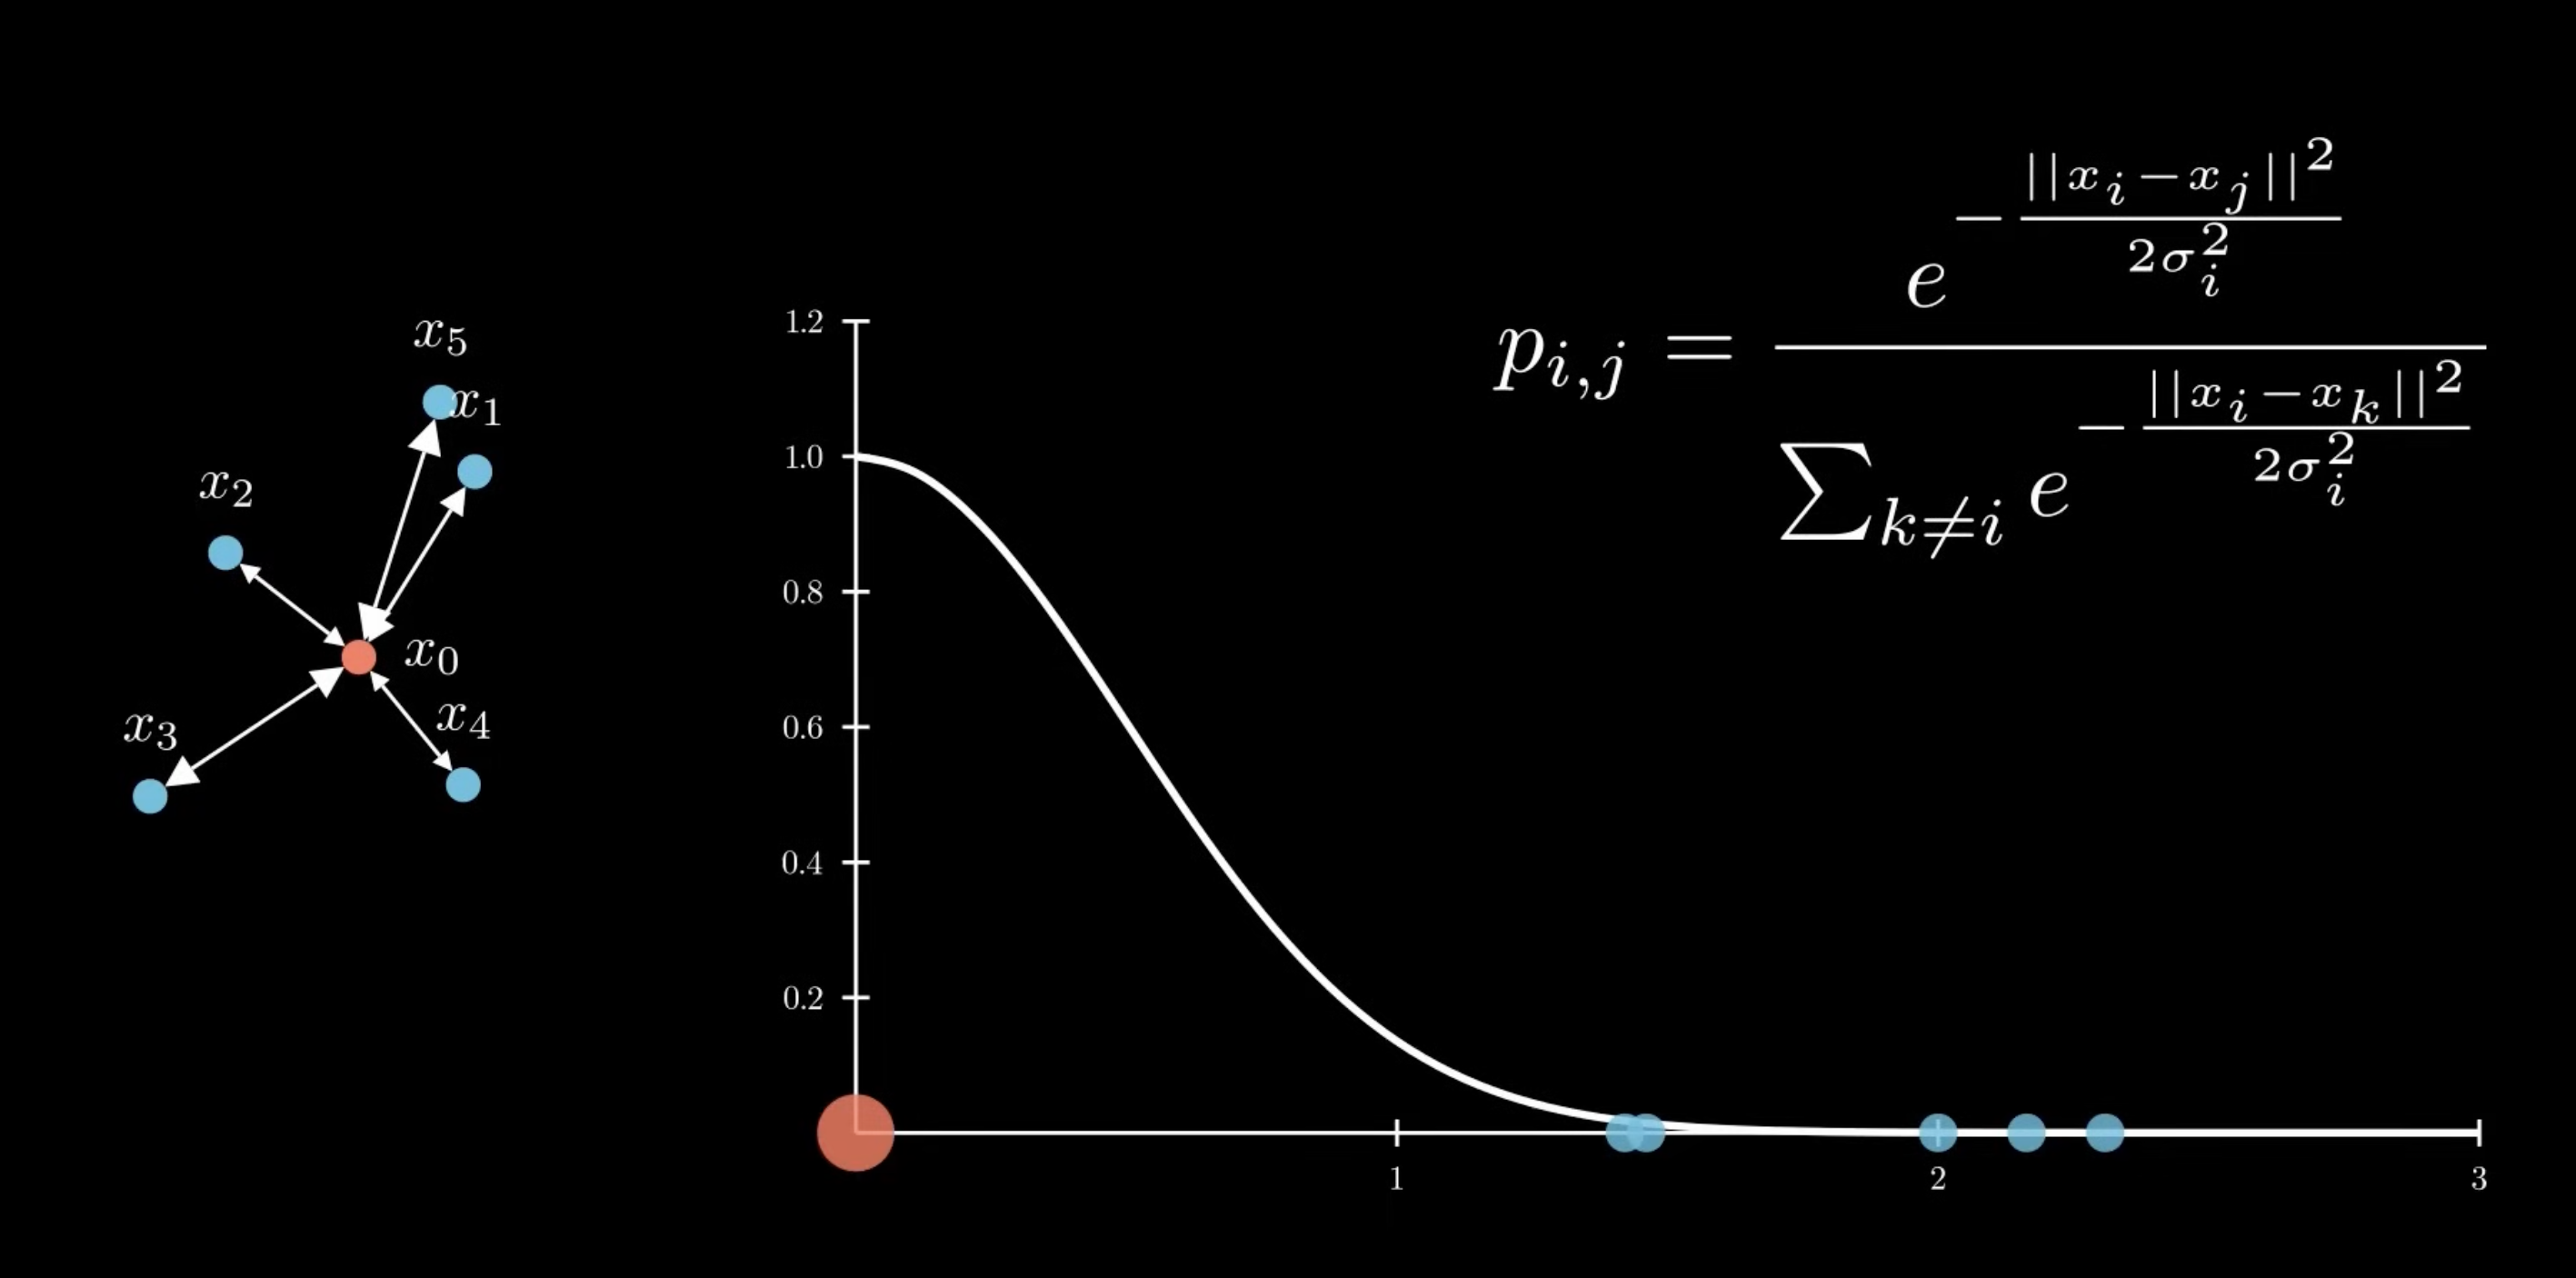


- Here, we compute the probability distributions for the points in high dimensional space
- Next, we also compute the probability distributions for the points in lower dimensional space

We use Kullback - Leibler divergence to find the distributions are similar

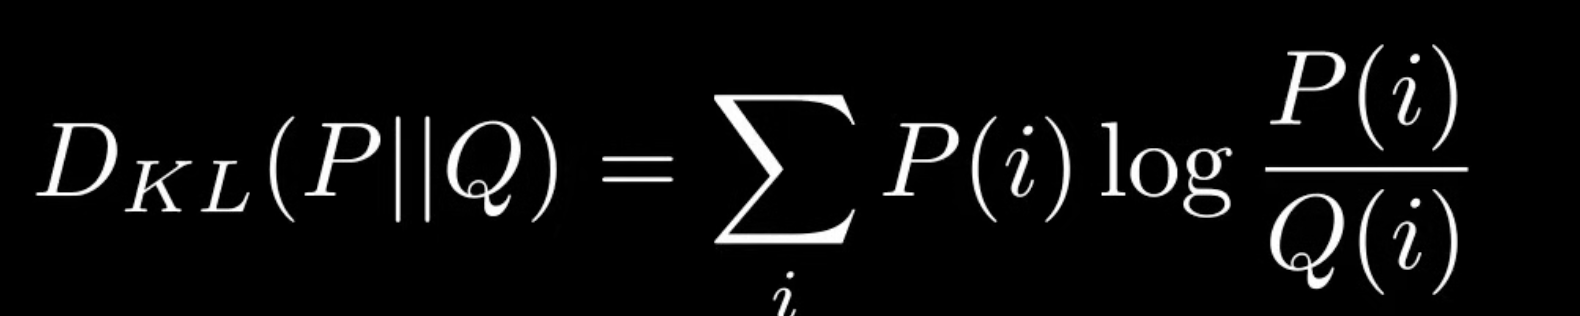

if the KL value is small, the distributions are very similar, and if it large, they're very different

Perplexity is an important hyperparameter. What it means is " represents the number of other points that a given point will consider as neighbors"

In [ ]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
sc.fit(X_train)
X_scaled = sc.transform(X_train)

### Step - 2.1 Experimentation - 1 ("Metrics = Euclidean")

In [ ]:
perplexity = np.arange(5, 100, 15)
divergence = []

for i in perplexity:
    model = TSNE(n_components=2, init="pca", perplexity=i)
    reduced = model.fit_transform(X_scaled)
    divergence.append(model.kl_divergence_)
    
fig = px.line(x=perplexity, y=divergence, markers=True)
fig.update_layout(xaxis_title="Perplexity Values", yaxis_title="Divergence")
fig.update_traces(line_color="red", line_width=1)
fig.show()

### Step - 2.1 Experimentation - 2 ("Metrics = Cosine")

In [ ]:
perplexity = np.arange(5, 100, 15)
divergence = []

for i in perplexity:
    model = TSNE(n_components=2, init="pca", perplexity=i,
                 metric = "cosine")
    reduced = model.fit_transform(X_scaled)
    divergence.append(model.kl_divergence_)
    
fig = px.line(x=perplexity, y=divergence, markers=True)
fig.update_layout(xaxis_title="Perplexity Values", yaxis_title="Divergence")
fig.update_traces(line_color="red", line_width=1)
fig.show()

So, 

- we go with metric = "euclidean" and perplexity = 100, scaling = False

- we go with metric = "cosine" and perplexity = 100, scaling = False

In [ ]:
tsne_model = TSNE(n_components=2, 
                    init="pca", 
                    perplexity=100, 
                    metric = "cosine")
X_tsne = tsne_model.fit_transform(X_scaled)
print(f"KL Divergence : {tsne_model.kl_divergence_}")

In [ ]:
fig = px.scatter(x=X_tsne[(y_train == "1") | (y_train == "2"), 0], y=X_tsne[(y_train == "1") | (y_train == "2"), 1], 
                 color=y_train[(y_train == "1") | (y_train == "2")])
fig.update_layout(
    title="t-SNE visualization of Custom Classification dataset",
    scene = dict(
                xaxis_title="First t-SNE Component",
                yaxis_title="Second t-SNE Component",
                #zaxis_title="Third t-SNE Component"
            )
)
fig.show()

In [ ]:
fig = px.scatter(x=X_tsne[(y_train == "0") | (y_train == "4"), 0], y=X_tsne[(y_train == "0") | (y_train == "4"), 1], 
                 color=y_train[(y_train == "0") | (y_train == "4")])
fig.update_layout(
    title="t-SNE visualization of Custom Classification dataset",
    scene = dict(
                xaxis_title="First t-SNE Component",
                yaxis_title="Second t-SNE Component",
                #zaxis_title="Third t-SNE Component"
            )
)
fig.show()

fig = px.scatter_3d(x=X_tsne[:, 0], y=X_tsne[:, 1], z=X_tsne[:, 2], color=y_train)
fig.update_layout(
    title="t-SNE visualization of Custom Classification dataset",
    scene = dict(
                xaxis_title="First t-SNE Component",
                yaxis_title="Second t-SNE Component",
                zaxis_title="Third t-SNE Component"
            )
)
fig.show()

## Step-3 Parametric T-SNE

In [ ]:
high_dims = X_scaled.shape[1]
num_outputs = 2
perplexity = 30
ptSNE = Parametric_tSNE(high_dims, num_outputs, perplexity)
ptSNE.fit(X_scaled, epochs = 20)
output_res = ptSNE.transform(X_scaled)

In [ ]:
fig = px.scatter(x=output_res[(y_train == "0") | (y_train == "4"), 0], y=output_res[(y_train == "0") | (y_train == "4"), 1], 
                 color=y_train[(y_train == "0") | (y_train == "4")])
fig.update_layout(
    title="t-SNE visualization of Custom Classification dataset",
    scene = dict(
                xaxis_title="First t-SNE Component",
                yaxis_title="Second t-SNE Component",
            )
)
fig.show()

In [ ]:
fig = px.scatter(x=output_res[:, 0], y=output_res[:, 1], 
                 color=y_train)
fig.update_layout(
    title="t-SNE visualization of Custom Classification dataset",
    scene = dict(
                xaxis_title="First t-SNE Component",
                yaxis_title="Second t-SNE Component",
                #zaxis_title="Third t-SNE Component"
            )
)
fig.show()

## Step -4 : Build Parametric T-SNE LSTM Model

### Step - 4.1 Build Parametric T-SNE Model

In [8]:
class BuildParametricTsneModel:

    def __init__(self, num_outputs: int, 
                        perplexity: int, 
                        scaling:bool, 
                        input_arr : np.ndarray, 
                        epochs : int):
        """ 
            Function : Build Parametric T-SNE Model 
            Arguments:
                num_outputs : int : lower dimension 
        """
        self.num_outputs = num_outputs
        self.perplexity = perplexity
        self.scaling = scaling
        self.epochs = epochs # Number of iterations
        self.input_arr = input_arr # Higher Dimensional Array

    @staticmethod
    def MinMaxScaling(input_arr:np.ndarray):
        sc = MinMaxScaler()
        sc.fit(input_arr)

        return sc

    def train(self):
        X_copy = self.input_arr.copy() # Copy 

        # Scaling
        if self.scaling == True:
            self.sc = BuildParametricTsneModel.MinMaxScaling(input_arr = X_copy)
            X_copy = self.sc.transform(X_copy)

        # Fit the Model
        self.ptSNE = Parametric_tSNE(X_copy.shape[1], 
                                    self.num_outputs, 
                                    self.perplexity)
        self.ptSNE.fit(X_copy, epochs = self.epochs)

    def fit(self, X: np.ndarray):
        # Scaling during Transform stage
        if self.scaling == True:
            X = self.sc.transform(X)

        X = self.ptSNE.transform(X)
        return X
        

ptsne_model = BuildParametricTsneModel(
    num_outputs= 10, 
    perplexity = 30, 
    scaling = True,
    input_arr = X_train, 
    epochs= 5
)

# Fit the Model
ptsne_model.train()

/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-19 11:13:21.191142: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


### Step - 4.2 Create a Tensorflow Train, Valid and Test Object

In [9]:
# Train, Valid and Test Model
X_Ptrain = ptsne_model.fit(X_train)
X_Pvalid = ptsne_model.fit(X_valid)
X_Ptest = ptsne_model.fit(X_test)

650/650 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [10]:
# Build Training, Validation and Testing Dataset
training_dataset = tf.data.Dataset.from_tensor_slices((X_Ptrain, y_train)).batch(BATCH_SIZE)
validation_dataset = tf.data.Dataset.from_tensor_slices((X_Pvalid, y_valid)).batch(BATCH_SIZE)
testing_dataset = tf.data.Dataset.from_tensor_slices((X_Ptest, y_test)).batch(BATCH_SIZE)

### Step - 4.3 Build Deep Neural Network Model

In [9]:
class DeepNN(Model):
    def __init__(self, num_classes):
        super(DeepNN, self).__init__()
        self.fc0 = Dense(256)
        self.act0 = LeakyReLU(alpha=0.1)
        self.bn = BatchNormalization()
        self.fc1 = Dense(128)
        self.act1 = LeakyReLU(alpha=0.1)
        self.fc2 = Dense(64)
        self.act2 = LeakyReLU(alpha=0.1)
        self.out_layer = Dense(num_classes, activation='softmax')

    def call(self, inputs, training=False):
        x = inputs
        x = self.act0(self.fc0(x))
        x = self.bn(x)
        x = self.act1(self.fc1(x))
        x = self.bn(x)
        x = self.act2(self.fc2(x))
        x = self.bn(x)
        return self.out_layer(x)


model = DeepNN(num_classes=5)
model.build(input_shape=(None, 10))

/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'deep_nn', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [22]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Dropout, Concatenate, Add

class RandomForestLikeNN(Model):
    def __init__(self, num_classes):
        super(RandomForestLikeNN, self).__init__()

        # --- Input dropout simulating random feature selection ---
        self.input_dropout = Dropout(0.2)

        # --- Branch 1 ---
        self.fc1a = Dense(128)
        self.act1a = LeakyReLU(alpha=0.1)
        self.bn1a = BatchNormalization()
        self.fc2a = Dense(64)
        self.act2a = LeakyReLU(alpha=0.1)
        self.bn2a = BatchNormalization()

        # --- Branch 2 ---
        self.fc1b = Dense(128)
        self.act1b = LeakyReLU(alpha=0.1)
        self.bn1b = BatchNormalization()
        self.fc2b = Dense(64)
        self.act2b = LeakyReLU(alpha=0.1)
        self.bn2b = BatchNormalization()

        # --- Branch 3 ---
        self.fc1c = Dense(128)
        self.act1c = LeakyReLU(alpha=0.1)
        self.bn1c = BatchNormalization()
        self.fc2c = Dense(64)
        self.act2c = LeakyReLU(alpha=0.1)
        self.bn2c = BatchNormalization()

        # --- Combine branches ---
        self.concat = Concatenate()
        self.fc_combined = Dense(128)
        self.act_combined = LeakyReLU(alpha=0.1)
        self.bn_combined = BatchNormalization()
        self.dropout = Dropout(0.3)

        # --- Skip connection ---
        self.skip_dense = Dense(128, activation='relu')

        # --- Output ---
        self.output_layer = Dense(num_classes, activation='softmax')

    def call(self, inputs, training=False):
        # Random feature dropout (like RF feature selection)
        x_input = self.input_dropout(inputs, training=training)

        # Branch 1
        x1 = self.bn1a(self.act1a(self.fc1a(x_input)))
        x1 = self.bn2a(self.act2a(self.fc2a(x1)))

        # Branch 2
        x2 = self.bn1b(self.act1b(self.fc1b(x_input)))
        x2 = self.bn2b(self.act2b(self.fc2b(x2)))

        # Branch 3
        x3 = self.bn1c(self.act1c(self.fc1c(x_input)))
        x3 = self.bn2c(self.act2c(self.fc2c(x3)))

        # Combine branches
        x = self.concat([x1, x2, x3])
        x = self.bn_combined(self.act_combined(self.fc_combined(x)))
        x = self.dropout(x, training=training)

        # Skip connection
        skip = self.skip_dense(x_input)
        x = Add()([x, skip])

        return self.output_layer(x)


# Example usage
model = RandomForestLikeNN(num_classes=4)
model.build(input_shape=(None, 320))
model.summary()


/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/tensorflow_env/lib/python3.9/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'random_forest_like_nn_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "random_forest_like_nn_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ concatenate_1 (Concatenate)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ ?                      │             

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Compile the Model
model.compile(optimizer= Adam(learning_rate= 0.001), 
                        loss = CategoricalFocalCrossentropy(), 
                        metrics = ["accuracy", "f1_score"])

In [24]:
# Early Stopping
early_stopping_callback = EarlyStopping(
    monitor = "val_loss",
    patience = 10,
    verbose = 1, 
    restore_best_weights = True, 
    mode = 'min'
)

# Model Check Pointing
model_check_point = ModelCheckpoint(
    filepath = "../model/baseline_model.keras",
    monitor = "val_loss",
    verbose = 1,
    save_best_only = True, 
)

callbacks = [early_stopping_callback, model_check_point]

In [25]:
history = model.fit(
    training_dataset,
    epochs = 100, 
    batch_size = BATCH_SIZE, 
    validation_data = validation_dataset, 
    #callbacks = [early_stopping_callback], 
    #class_weight = class_weights
)

Epoch 1/100


2025-10-20 11:37:48.876528: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


336/336 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.3150 - f1_score: 0.3147 - loss: 0.4314 - val_accuracy: 0.3618 - val_f1_score: 0.3615 - val_loss: 0.2269
Epoch 2/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.3397 - f1_score: 0.3392 - loss: 0.2560 - val_accuracy: 0.3527 - val_f1_score: 0.3515 - val_loss: 0.2064
Epoch 3/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.3517 - f1_score: 0.3512 - loss: 0.2165 - val_accuracy: 0.3806 - val_f1_score: 0.3798 - val_loss: 0.1879
Epoch 4/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.3750 - f1_score: 0.3747 - loss: 0.1985 - val_accuracy: 0.3828 - val_f1_score: 0.3816 - val_loss: 0.1863
Epoch 5/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.3841 - f1_score: 0.3842 - loss: 0.1898 - val_accuracy: 0.3860 - val_f1_score: 0.3850 - val_loss: 0.1828
Epoch 6/100
336/336 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.3883 - f1_score: 0.3877 - loss: 0.1879 - val_accuracy: 0.3919 - val_f1_score: 

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.31      0.27      0.29       503
           1       0.28      0.24      0.25       499
           2       0.27      0.32      0.29       452
           3       0.27      0.30      0.29       452

    accuracy                           0.28      1906
   macro avg       0.28      0.28      0.28      1906
weighted avg       0.28      0.28      0.28      1906



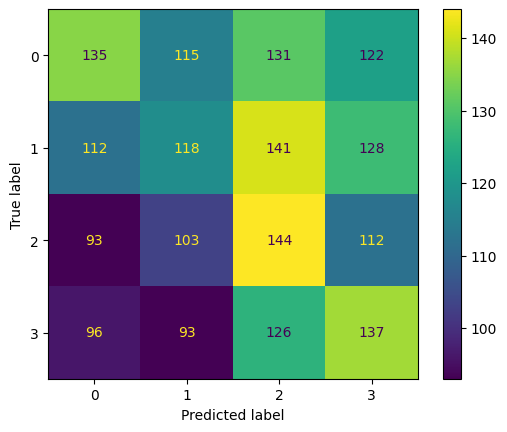

In [28]:
# Test Predictions
y_test_pred = model.predict(testing_dataset)
y_test_pred = np.argmax(y_test_pred, axis = 1)

# Original Predictions
y_test_original = np.concatenate([y.numpy() for x, y in testing_dataset])
y_test_original = np.argmax(y_test_original, axis = 1)


# Confusion Matrix
cm = confusion_matrix(y_test_original, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3])
disp.plot() # will appear at the end of the output
print(classification_report(y_test_original, y_test_pred, ))

116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.48      0.55      0.51      1780
           1       0.15      0.14      0.14       503
           2       0.15      0.09      0.11       499
           3       0.12      0.12      0.12       452
           4       0.13      0.13      0.13       452

    accuracy                           0.33      3686
   macro avg       0.21      0.20      0.20      3686
weighted avg       0.30      0.33      0.31      3686



2025-10-19 11:38:18.395310: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


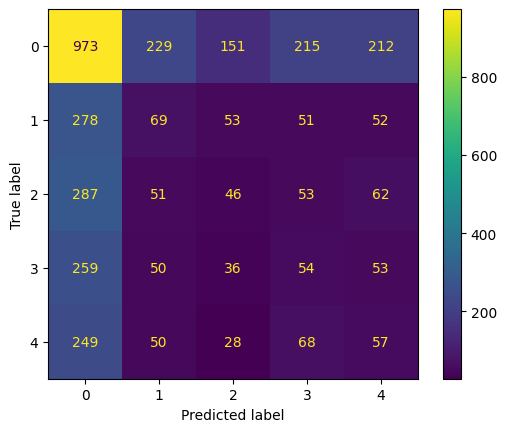

In [8]:
# Test Predictions
y_test_pred = model.predict(testing_dataset)
y_test_pred = np.argmax(y_test_pred, axis = 1)

# Original Predictions
y_test_original = np.concatenate([y.numpy() for x, y in testing_dataset])
y_test_original = np.argmax(y_test_original, axis = 1)


# Confusion Matrix
cm = confusion_matrix(y_test_original, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3, 4])
disp.plot() # will appear at the end of the output
print(classification_report(y_test_original, y_test_pred, ))